# 1. EDA: Indeed Hiring Lab Sectors + Headline
Seasonally unadjusted

#### Combining the 2 dataframes and then visualizing the data, finding similarities among variables, and seeing how the data interacts with itself.
#### 

In [49]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import glob


In [50]:
# === Step 1: Load and Inspect Dataset for Sectoral===
# Was working to get the average of the overlapping NEW and TOTAL job postings with overlapping dateString
# Moving on for now for sake of speed
DATA_PATH_sectoral = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"
csv_files_sectoral = glob.glob(os.path.join(DATA_PATH_sectoral, "*.csv"))

dataframes = []

for file in csv_files_sectoral:
    # Read each CSV file
    df_temp = pd.read_csv(file)    
    # Add a column to identify which file the data came from
    df_temp['source_file'] = os.path.basename(file)
    
    # Add to our list of dataframes
    dataframes.append(df_temp)
    
    print(f"Loaded {file}: {df_temp.shape[0]} rows, {df_temp.shape[1]} columns")

# Combine all dataframes using pd.concat()
sectoral_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined dataframe shape: {sectoral_df.shape}")
print(f"Total rows: {len(sectoral_df)}")
print(f"Total columns: {len(sectoral_df.columns)}")


print("Data types: \n", sectoral_df.dtypes, "\n ---")
print("Data info: \n", sectoral_df.info(), "\n ---")

sectoral_df = sectoral_df[sectoral_df['postingType'] != 'NEW'].copy()

sectoral_df


<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
C:\Users\rojas\AppData\Local\Temp\ipykernel_58864\334529888.py:4: SyntaxWarning: invalid escape sequence '\g'
  DATA_PATH_sectoral = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"


Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\accounting_admin-assist_architecture-arts+entertainment_banking+finance_childcare_civilengineering.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\cleaning+sanitation_community+social-service_construction_customer-service_data-analytics_dental_driving.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\education-instruction_electrical-engineering_food-prep+service_hospitality+tourism_human-resources_IT-infrastructure_IT-systems.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\industrial-engineering_installation+maintenance_legal_loading+stocking_logistic-support_management_marketing.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\m

,__typename,dateString,countryCode,countryName,sectorCode,sectorName,postingType,value,source_file
0,HiringLabSectoralPosting,2020-02-01,US,United States,accounting,Accounting,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
1,HiringLabSectoralPosting,2020-02-01,US,United States,admin,Administrative Assistance,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
2,HiringLabSectoralPosting,2020-02-01,US,United States,arch,Architecture,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
3,HiringLabSectoralPosting,2020-02-01,US,United States,arts,Arts & Entertainment,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
4,HiringLabSectoralPosting,2020-02-01,US,United States,childcare,Childcare,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
...,...,...,...,...,...,...,...,...,...
92605,HiringLabSectoralPosting,2025-09-18,US,United States,therapy,Therapy,TOTAL,195.99,sports_therapy_veterinary.csv
92606,HiringLabSectoralPosting,2025-09-18,US,United States,veterinary,Veterinary,TOTAL,148.98,sports_therapy_veterinary.csv
92607,HiringLabSectoralPosting,2025-09-19,US,United States,sports,Sports,TOTAL,153.11,sports_therapy_veterinary.csv
92608,HiringLabSectoralPosting,2025-09-19,US,United States,therapy,Therapy,TOTAL,195.85,sports_therapy_veterinary.csv


In [51]:
# === Step 2: Load and Inspect Dataset for Headline ===
DATA_PATH_headline = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Total_US_Market\job-postings-headline-index-no-seasonal-adjustement.csv"
headline_df = pd.read_csv(DATA_PATH_headline)
print("Data types: \n", headline_df.dtypes, "\n ---")
print("Data info: \n", headline_df.info(), "\n ---")
headline_df['source_file'] = 'job-postings-headline-index-no-seasonal-adjustement.csv'
headline_df['sectorName'] = 'Headline'
headline_df['sectorCode'] = 'Headline'
headline_df

Data types: 
 __typename      object
dateString      object
countryCode     object
countryName     object
postingType     object
value          float64
dtype: object 
 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   __typename   2058 non-null   object 
 1   dateString   2058 non-null   object 
 2   countryCode  2058 non-null   object 
 3   countryName  2058 non-null   object 
 4   postingType  2058 non-null   object 
 5   value        2058 non-null   float64
dtypes: float64(1), object(5)
memory usage: 96.6+ KB
Data info: 
 None 
 ---


<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\rojas\AppData\Local\Temp\ipykernel_58864\2761932370.py:2: SyntaxWarning: invalid escape sequence '\g'
  DATA_PATH_headline = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Total_US_Market\job-postings-headline-index-no-seasonal-adjustement.csv"


,__typename,dateString,countryCode,countryName,postingType,value,source_file,sectorName,sectorCode
0,HiringLabNationalPosting,2020-02-01,US,United States,TOTAL,100.00,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
1,HiringLabNationalPosting,2020-02-02,US,United States,TOTAL,100.06,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2,HiringLabNationalPosting,2020-02-03,US,United States,TOTAL,100.09,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
3,HiringLabNationalPosting,2020-02-04,US,United States,TOTAL,100.18,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
4,HiringLabNationalPosting,2020-02-05,US,United States,TOTAL,100.29,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
...,...,...,...,...,...,...,...,...,...
2053,HiringLabNationalPosting,2025-09-15,US,United States,TOTAL,108.51,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2054,HiringLabNationalPosting,2025-09-16,US,United States,TOTAL,108.47,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2055,HiringLabNationalPosting,2025-09-17,US,United States,TOTAL,108.45,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline
2056,HiringLabNationalPosting,2025-09-18,US,United States,TOTAL,108.39,job-postings-headline-index-no-seasonal-adjust...,Headline,Headline


In [52]:
# === Step 3: Combine the dataframes for Headline and Sectoral ===
combined_df = pd.merge(headline_df, sectoral_df, on=['sectorName','sectorCode','source_file','dateString', 'countryCode', 'postingType','countryName','__typename','value'], how='outer')

print(f"\nCombined dataframe shape: {combined_df.shape}")
print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")


print("Data types: \n", combined_df.dtypes, "\n ---")
print("Data info: \n", combined_df.info(), "\n ---")

combined_df



Combined dataframe shape: (94668, 9)
Total rows: 94668
Total columns: 9
Data types: 
 __typename      object
dateString      object
countryCode     object
countryName     object
postingType     object
value          float64
source_file     object
sectorName      object
sectorCode      object
dtype: object 
 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94668 entries, 0 to 94667
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   __typename   94668 non-null  object 
 1   dateString   94668 non-null  object 
 2   countryCode  94668 non-null  object 
 3   countryName  94668 non-null  object 
 4   postingType  94668 non-null  object 
 5   value        94668 non-null  float64
 6   source_file  94668 non-null  object 
 7   sectorName   94668 non-null  object 
 8   sectorCode   94668 non-null  object 
dtypes: float64(1), object(8)
memory usage: 6.5+ MB
Data info: 
 None 
 ---


,__typename,dateString,countryCode,countryName,postingType,value,source_file,sectorName,sectorCode
0,HiringLabSectoralPosting,2020-02-01,US,United States,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
1,HiringLabSectoralPosting,2020-02-02,US,United States,TOTAL,99.97,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
2,HiringLabSectoralPosting,2020-02-03,US,United States,TOTAL,99.89,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
3,HiringLabSectoralPosting,2020-02-04,US,United States,TOTAL,99.81,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
4,HiringLabSectoralPosting,2020-02-05,US,United States,TOTAL,99.82,accounting_admin-assist_architecture-arts+ente...,Accounting,accounting
...,...,...,...,...,...,...,...,...,...
94663,HiringLabSectoralPosting,2025-09-15,US,United States,TOTAL,148.49,sports_therapy_veterinary.csv,Veterinary,veterinary
94664,HiringLabSectoralPosting,2025-09-16,US,United States,TOTAL,148.85,sports_therapy_veterinary.csv,Veterinary,veterinary
94665,HiringLabSectoralPosting,2025-09-17,US,United States,TOTAL,149.01,sports_therapy_veterinary.csv,Veterinary,veterinary
94666,HiringLabSectoralPosting,2025-09-18,US,United States,TOTAL,148.98,sports_therapy_veterinary.csv,Veterinary,veterinary


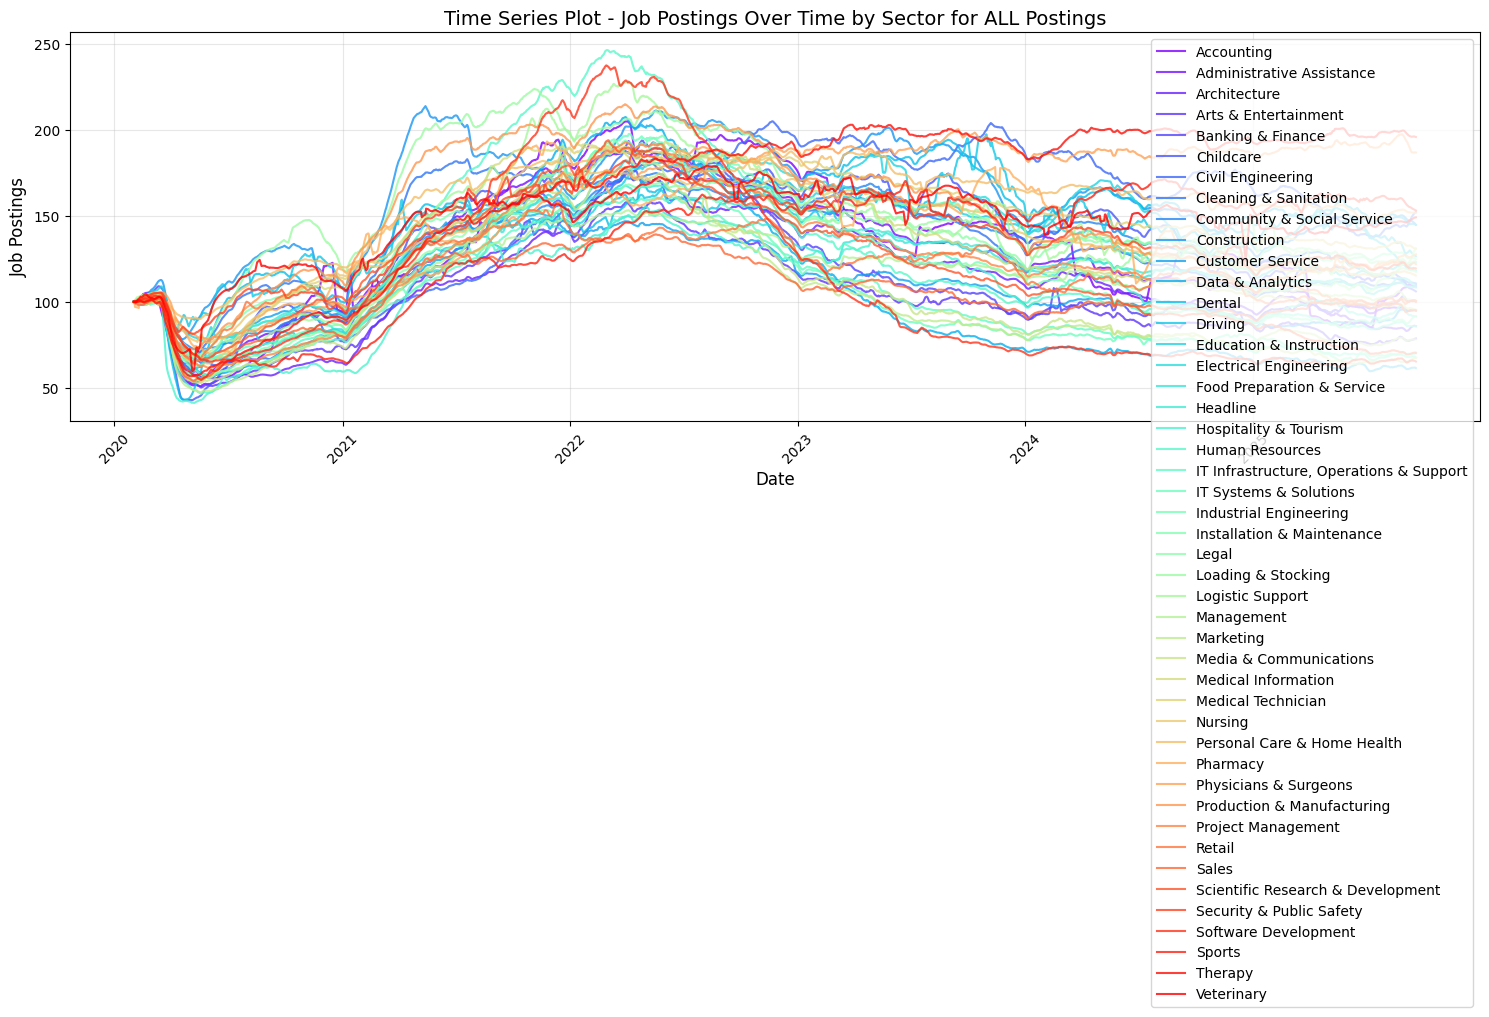

In [53]:
# Now let's create a simple time-series plot
# First, we need to convert the dateString column to a datetime object using pd.to_datetime
combined_df['dateString'] = pd.to_datetime(combined_df['dateString'])

# Set up the plot
plt.figure(figsize=(15, 8))

sectors = combined_df['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = combined_df[combined_df['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'], label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for ALL Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

Now we want to understand what sector has the most influence on the headline dataset from the job posting datasets

In [61]:
# to do this, convert dateString->datetime and make pivot table
combined_df['dateString'] = pd.to_datetime(combined_df['dateString'])

pivot_df = combined_df.pivot_table(
    index='dateString',
    columns='sectorName',
    values='value',
    aggfunc='mean'
)
print("")
# === Step 2: Calculate the correlation matrix ===


correlation_matrix = pivot_df.corr()

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
print("\nCorrelation matrix:")
print(correlation_matrix)

# === Step 3: Extract correlations with headline ===
headline_correlations = correlation_matrix['Headline'].drop('Headline')

headline_correlations_sorted = headline_correlations.abs().sort_values(ascending=False)

print("\nSector correlations with Headline (sorted by strength):")
print(headline_correlations_sorted)

print("\nDetailed correlations with Headline:")
detailed_correlations = headline_correlations.sort_values(ascending=False)
print(detailed_correlations)



Correlation matrix shape: (46, 46)

Correlation matrix:
sectorName                               Accounting  \
sectorName                                            
Accounting                                 1.000000   
Administrative Assistance                  0.949189   
Architecture                               0.928967   
Arts & Entertainment                       0.922124   
Banking & Finance                          0.896994   
Childcare                                  0.850038   
Civil Engineering                          0.666509   
Cleaning & Sanitation                      0.838609   
Community & Social Service                 0.877244   
Construction                               0.748908   
Customer Service                           0.828390   
Data & Analytics                           0.827007   
Dental                                     0.657778   
Driving                                    0.732483   
Education & Instruction                    0.707168   
Electri

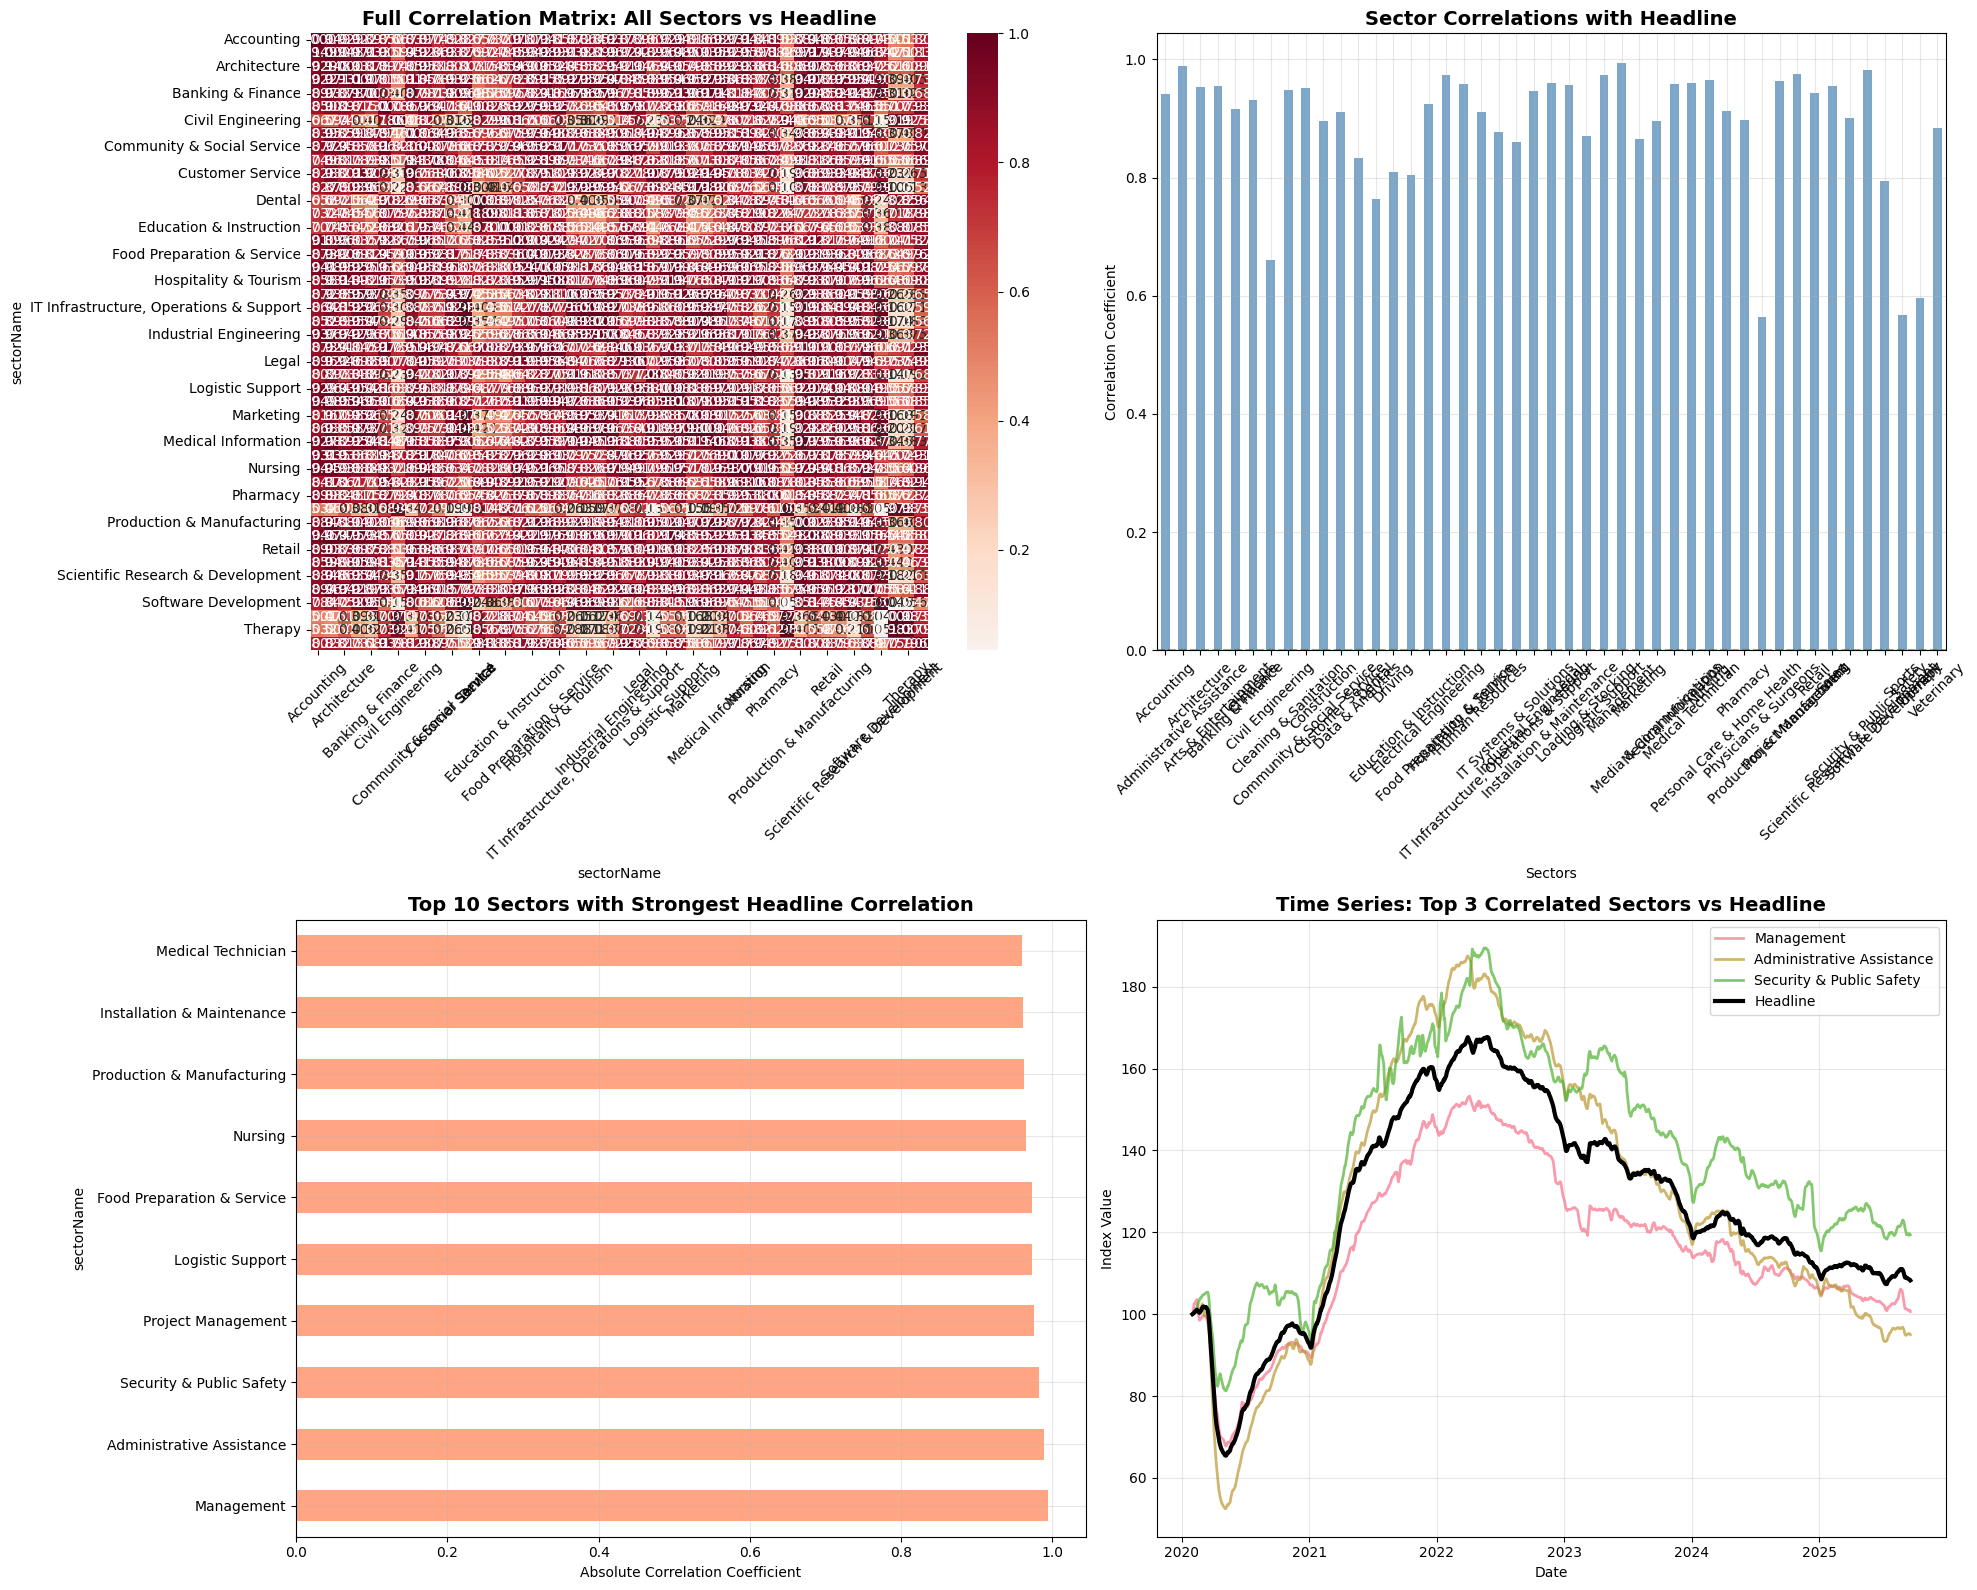

In [62]:
# === Step 4: Create beautiful visualizations ===
# set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Correlation heatmap (full matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', ax=axes[0,0])
axes[0,0].set_title('Full Correlation Matrix: All Sectors vs Headline', fontsize=14, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].tick_params(axis='y', rotation=0)

# Plot 2: Bar chart of headline correlations
headline_correlations.plot(kind='bar', ax=axes[0,1], color='steelblue', alpha=0.7)
axes[0,1].set_title('Sector Correlations with Headline', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Sectors')
axes[0,1].set_ylabel('Correlation Coefficient')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Top 10 strongest correlations (absolute value)
top_10 = headline_correlations.abs().nlargest(10)
top_10.plot(kind='barh', ax=axes[1,0], color='coral', alpha=0.7)
axes[1,0].set_title('Top 10 Sectors with Strongest Headline Correlation', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Absolute Correlation Coefficient')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Time series of top 3 correlated sectors vs headline
top_3_sectors = headline_correlations.abs().nlargest(3).index
for sector in top_3_sectors:
    axes[1,1].plot(pivot_df.index, pivot_df[sector], label=f'{sector}', alpha=0.7, linewidth=2)

axes[1,1].plot(pivot_df.index, pivot_df['Headline'], label='Headline', color='black', linewidth=3)
axes[1,1].set_title('Time Series: Top 3 Correlated Sectors vs Headline', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Index Value')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
# === Step 5: Statistical summary ===
print("=== COLLINEARITY ANALYSIS SUMMARY ===")
print(f"Total sectors analyzed: {len(headline_correlations)}")
print(f"Date range: {pivot_df.index.min().strftime('%Y-%m-%d')} to {pivot_df.index.max().strftime('%Y-%m-%d')}")
print(f"Number of data points: {len(pivot_df)}")

print(f"\n=== TOP 5 STRONGEST POSITIVE CORRELATIONS ===")
positive_corr = headline_correlations[headline_correlations > 0].nlargest(5)
for sector, corr in positive_corr.items():
    print(f"{sector}: {corr:.4f}")

print(f"\n=== TOP 5 STRONGEST NEGATIVE CORRELATIONS ===")
negative_corr = headline_correlations[headline_correlations < 0].nsmallest(5)
for sector, corr in negative_corr.items():
    print(f"{sector}: {corr:.4f}")

print(f"\n=== SECTORS WITH WEAK CORRELATIONS (< 0.3) ===")
weak_corr = headline_correlations[headline_correlations.abs() < 0.3]
print(f"Count: {len(weak_corr)}")
print(weak_corr.sort_values(ascending=False))

=== COLLINEARITY ANALYSIS SUMMARY ===
Total sectors analyzed: 45
Date range: 2020-02-01 to 2025-09-19
Number of data points: 2058

=== TOP 5 STRONGEST POSITIVE CORRELATIONS ===
Management: 0.9943
Administrative Assistance: 0.9890
Security & Public Safety: 0.9818
Project Management: 0.9758
Logistic Support: 0.9734

=== TOP 5 STRONGEST NEGATIVE CORRELATIONS ===

=== SECTORS WITH WEAK CORRELATIONS (< 0.3) ===
Count: 0
Series([], Name: Headline, dtype: float64)
